# U.S. GDP Curve Fitting Project

## Introduction

In [41]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28,
              29, 33, 37, 41, 42, 43, 45, 49, 54, 56])
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
              1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])
print(x)

[ 1  5  9 13 17 19 22 25 27 28 29 33 37 41 42 43 45 49 54 56]


## Part A: Cubic Spline

In [42]:
def setup_tridiagonal_matrix(x, y):
    """
    Constructs coefficients arrays for tridiagonal system to solve for second derivatives
    """
    h = np.diff(x)
    A = []
    B = []
    C = []
    D = []
    
    for i in range(1, len(x)-1):
        leftSlope = (y[i] - y[i-1]) / h[i-1]
        rightSlope = (y[i+1] - y[i]) / h[i]
        A.append(h[i-1])
        B.append(2 * (h[i-1] + h[i]))
        C.append(h[i])
        D.append(6 * (rightSlope - leftSlope))
        
    return A, B, C, D

In [43]:
def thomas_algorithm(a, b, c, d):
    """
    Solves tridiagonal system
    """
    n = len(b)
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    m = np.concatenate(([0], x, [0]))
    return m

In [44]:
def evaluate_spline(x, y, m, xeval):
    """
    Uses the second derivatives to compute the spline value at any point given
    """
    lowerBound = 0
    upperBound = 1
    for i in range(len(x)-1):
        if (x[i] <= xeval <= x[i+1]):
            lowerBound = i
            upperBound = i+1
            break
    xL = x[lowerBound]
    xU = x[upperBound]
    yL = y[lowerBound]
    yU = y[upperBound]
    mL = m[lowerBound]
    mU = m[upperBound]
    h = xU - xL
    leftCurve = mL * (xU - xeval)**3 / (6*h)
    rightCurve = mU * (xeval - xL)**3 / (6*h)
    left = (yL - mL*h**2/6) * (xU - xeval) / h
    right = (yU - mU*h**2/6) * (xeval - xL) / h
    yValue = leftCurve + rightCurve + left + right
    return yValue

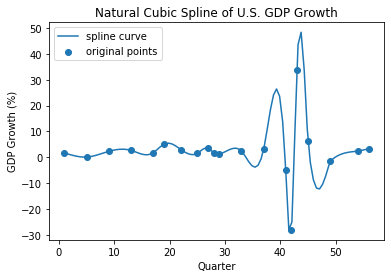

In [52]:
a, b, c, d = setup_tridiagonal_matrix(x, y)
m = thomas_algorithm(a, b, c, d)
xnew = np.linspace(min(x), max(x),100)
ynew = []
for i in xnew:
    ynew.append(evaluate_spline(x, y, m, i))
plt.scatter(x, y, label="original points")
plt.plot(xnew, ynew, label = "spline curve")
plt.legend()
plt.xlabel("Quarter")
plt.ylabel("GDP Growth (%)")
plt.title("Natural Cubic Spline of U.S. GDP Growth")
plt.show()

We are solving for the second derivative at each point. With 20 data points, there are 18 unknowns because natural spline boundary gives that the second derivative at the endpoints is zero. At each interior knot, it is required that the spline satisfies: the continuity of the function, the first derivative, and the second derivative match. This means each segment matches in value, slope, and concavity. 
The interpolant is visually smooth in most regions of the graph; however, in the COVID-19 region, large oscillation is exhibited between points. This is due to the spline trying to interpolate these outlier points, leading to an unrealistic curve in the graph. As a result, the graph is not a fully accurate or reasonable representation of data in these areas.
The spline passes through two severe outliers, 2020 Q2 and Q3 with a value of -28.1 and 33.8 respectively. This causes the interpolant to bend and produce large oscillations. This reflects the Runge phenomenon, where interpolating in high order can lead to large oscillations. Forcing the interpolation to be exact between these vastly differing values leads to the gra

## Part B: Polynomial & Least Squares

In [46]:
def leastSq(X,Y):
    n = len(X)
    sumX = sum(X)
    sumY = sum(Y)
    sumX2 = sum(X**2)
    sumXY = sum(X*Y)
    m = ((n * sumXY) - (sumX * sumY))/((n * sumX2) - (sumX**2))
    c = (sumY - (m * sumX))/n
    return m,c

In [47]:
def polyLeastSq(x, y, degree):
    A = []
    for num in x:
        row = []
        for i in range(0,degree+1):
            row.append(num**i)
        A.append(row)
    A = np.array(A)
    y = np.array(y)
    AT = A.T
    ATA = AT @ A
    ATy = AT @ y
    c = np.linalg.solve(ATA, ATy)
    return c

In [48]:
def evalPoly(c, xvals):
    yval = []
    for x in xvals:
        total = 0
        for num in range(len(c)):
            total += c[num] * (x**num)
        yval.append(total)
    return yval

In [49]:
def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

In [50]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

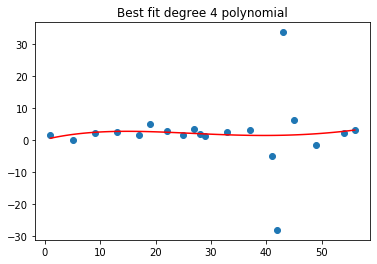

In [51]:
xSpread = np.linspace(min(x), max(x),100)
c4 = polyLeastSq(x, y, 4)
ypoly = evalPoly(c4, xSpread)

plt.scatter(x, y, label="GDP Growth data")
plt.plot(xSpread, ypoly, color="red")
plt.title("Best fit degree 4 polynomial")
plt.show()

## Part C: Method Justification

## Conclusion